In [20]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Lenovo\Downloads\Train.csv")
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [21]:
df.tail()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1
10995,10996,B,Ship,4,1,232,5,medium,F,6,1247,0
10996,10997,C,Ship,5,4,242,5,low,F,4,1155,0
10997,10998,F,Ship,5,2,223,6,medium,M,2,1210,0
10998,10999,D,Ship,2,5,155,5,low,F,6,1639,0


In [22]:
len(df.columns)

12

In [23]:
df.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

In [24]:
df.isnull().sum()

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [27]:
df.describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


Exploratory Data Analysis(EDA)

In [28]:
df.Mode_of_Shipment.value_counts()

Mode_of_Shipment
Ship      7462
Flight    1777
Road      1760
Name: count, dtype: int64

In [29]:
df['Reached.on.Time_Y.N'].value_counts()

Reached.on.Time_Y.N
1    6563
0    4436
Name: count, dtype: int64

What percentage of shipments are delayed?

In [30]:
df['Reached.on.Time_Y.N'].value_counts(normalize=True)*100

Reached.on.Time_Y.N
1    59.669061
0    40.330939
Name: proportion, dtype: float64

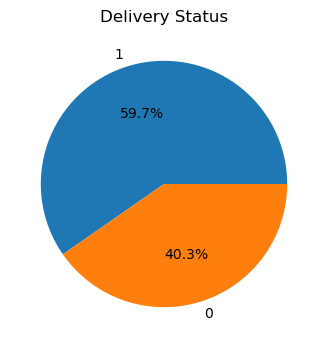

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

df['Reached.on.Time_Y.N'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(4,4)
)

plt.title('Delivery Status')
plt.ylabel('')
plt.show()

Which shipment mode causes more delays?

In [32]:
pd.crosstab(
    df['Mode_of_Shipment'],
    df['Reached.on.Time_Y.N']
)

Reached.on.Time_Y.N,0,1
Mode_of_Shipment,,
Flight,708,1069
Road,725,1035
Ship,3003,4459


In [33]:
import seaborn as sns 

<Axes: xlabel='Mode_of_Shipment', ylabel='Reached.on.Time_Y.N'>

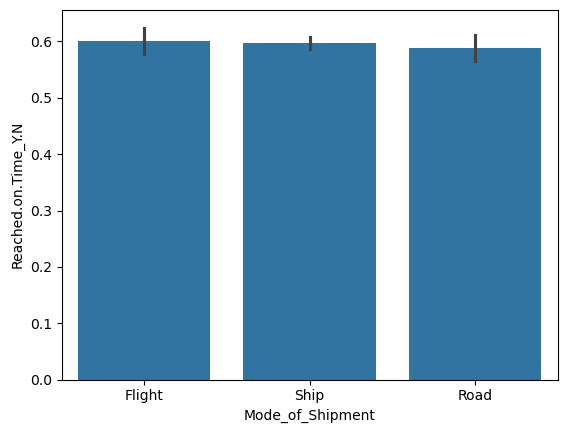

In [34]:
sns.barplot(
x='Mode_of_Shipment',
y='Reached.on.Time_Y.N',
data=df
)

Does discount affect delivery?

<Axes: xlabel='Reached.on.Time_Y.N', ylabel='Discount_offered'>

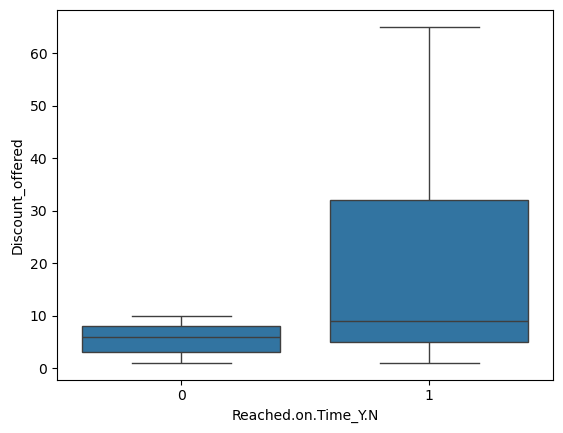

In [35]:
sns.boxplot(
x='Reached.on.Time_Y.N',
y='Discount_offered',
data=df
)

Insight:

Higher discounts may be linked with delayed deliveries.

<Axes: xlabel='Mode_of_Shipment', ylabel='count'>

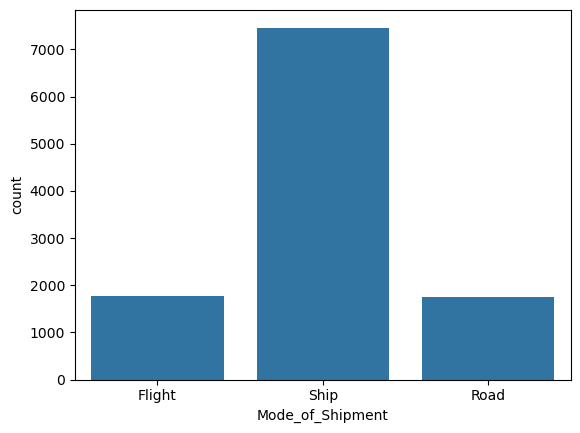

In [36]:
sns.countplot(x=df.Mode_of_Shipment)

Which warehouse has the most delays?

In [37]:
pd.crosstab(
df['Warehouse_block'],
df['Reached.on.Time_Y.N']
)

Reached.on.Time_Y.N,0,1
Warehouse_block,,
A,758,1075
B,729,1104
C,739,1094
D,738,1096
F,1472,2194


<Axes: xlabel='Warehouse_block', ylabel='Reached.on.Time_Y.N'>

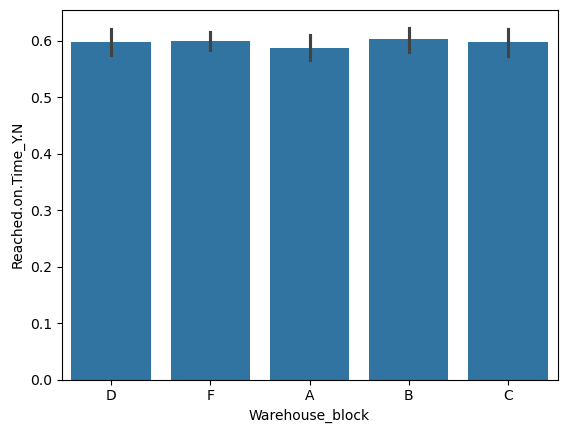

In [38]:
sns.barplot(data=df, x='Warehouse_block',y='Reached.on.Time_Y.N')

Does product weight affect delay?

<Axes: xlabel='Weight_in_gms', ylabel='Count'>

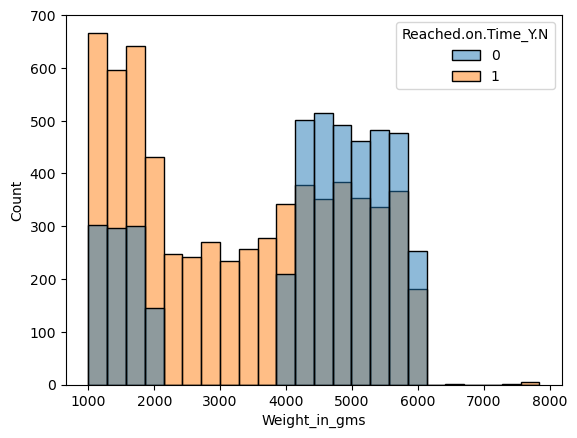

In [39]:
sns.histplot(
data=df,
x='Weight_in_gms',
hue='Reached.on.Time_Y.N'
)

Does product importance affect delivery

In [40]:
pd.crosstab(
df['Product_importance'],
df['Reached.on.Time_Y.N']
)

Reached.on.Time_Y.N,0,1
Product_importance,,
high,332,616
low,2157,3140
medium,1947,2807


<BarContainer object of 10999 artists>

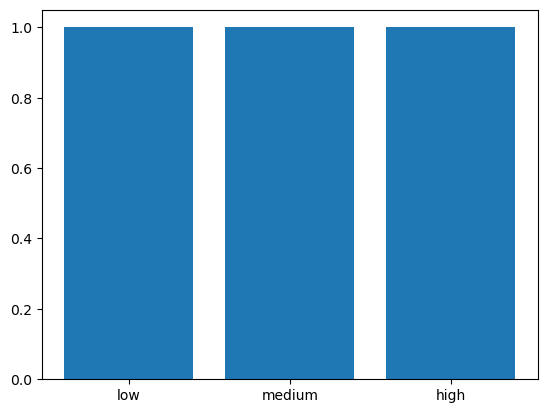

In [41]:
plt.bar( x=df['Product_importance'],height=df['Reached.on.Time_Y.N'])

In [52]:
df.to_csv(r'C:\Users\Lenovo\Downloads\data analasys\projects\shipping.csv')